# Benchmark de SAN en GPU

Evalúa el checkpoint disponible de **SAN** sobre CROHME: exact match, distancia de edición ≤1 y ≤2, CER tokenizado, FLOPs estimados, latencia y VRAM. La latencia y los FLOPs se obtienen en pasadas separadas para que el profiler no contamine los tiempos. Los resultados se guardan en `01_seleccion/resultados`.

In [1]:
from pathlib import Path
import gc, json, os, platform, sys, time
os.environ.setdefault('KINETO_LOG_LEVEL', '5')
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents, Path.cwd() / '..', Path.cwd() / '../..']:
        candidate = candidate.resolve()
        if (candidate / 'SAN').is_dir() and (candidate / 'data').is_dir(): return candidate
    raise FileNotFoundError('No se encontró la raíz con SAN/ y data/.')
ROOT = find_project_root()
SAN_ROOT = ROOT / 'SAN'
RESULTS_DIR = ROOT / 'Cascada' / '01_seleccion' / 'resultados'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DEVICE, MB = torch.device('cuda:0'), 1024 ** 2
assert torch.cuda.is_available(), 'CUDA no está disponible.'
print('Raíz:', ROOT); print('GPU:', torch.cuda.get_device_name(0)); print('PyTorch:', torch.__version__)

Raíz: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
PyTorch: 2.0.1+cu118


## Carga del modelo y del checkpoint

In [2]:
sys.path.insert(0, str(SAN_ROOT))
from utils import load_config
from infer.Backbone import Backbone
from dataset import Words
params = load_config(SAN_ROOT / '14.yaml')
params['device'] = DEVICE
params['word_path'] = str(SAN_ROOT / 'data' / 'word.txt')
params['checkpoint'] = str(SAN_ROOT / 'checkpoints' / 'SAN_decoder' / 'best.pth')
words = Words(params['word_path'])
params['word_num'], params['struct_num'], params['words'] = len(words), 7, words
model = Backbone(params)
state = torch.load(params['checkpoint'], map_location='cpu', weights_only=True)
model.load_state_dict(state['model'])
model = model.to(DEVICE).eval().requires_grad_(False)
torch.cuda.synchronize()
parameter_count = sum(p.numel() for p in model.parameters())
parameter_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
buffer_bytes = sum(b.numel() * b.element_size() for b in model.buffers())
model_allocated_mib = torch.cuda.memory_allocated() / MB
print(f'Parámetros: {parameter_count:,} ({parameter_count / 1e6:.3f} M)')
print(f'Pesos + buffers: {(parameter_bytes + buffer_bytes) / MB:.2f} MiB')
print(f'VRAM asignada tras cargar: {model_allocated_mib:.2f} MiB')

try UTF-8 encoding
115 symbols in total


Parámetros: 7,996,103 (7.996 M)
Pesos + buffers: 30.55 MiB
VRAM asignada tras cargar: 30.70 MiB


C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\.venv-hmer-gpu\lib\site-packages\torch\_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


In [3]:
def prediction_to_latex(prediction):
    if prediction is None or len(prediction) <= 1: return '<sin predicción>'
    children = {}
    for item in prediction:
        if len(item) < 4: continue
        try: node_id, parent_id = int(item[1]), int(item[2])
        except (TypeError, ValueError): continue
        children.setdefault(parent_id, []).append((node_id, str(item[3])))
    def walk(node_id):
        if node_id < 0 or node_id >= len(prediction): return ['<invalid>']
        symbol, kids = str(prediction[node_id][0]), children.get(node_id, [])
        if not kids: return [symbol]
        result = [symbol]
        if symbol == r'\frac':
            for relation_name in ('Above', 'Below'):
                for child_id, relation in kids:
                    if relation == relation_name: result += ['{'] + walk(child_id) + ['}']
            for child_id, relation in kids:
                if relation == 'Right': result += walk(child_id)
            return result
        for child_id, relation in kids:
            if relation == 'l_sup': result += ['['] + walk(child_id) + [']']
        for child_id, relation in kids:
            if relation == 'Inside': result += ['{'] + walk(child_id) + ['}']
        for child_id, relation in kids:
            if relation in ('Sub', 'Below'): result += ['_', '{'] + walk(child_id) + ['}']
        for child_id, relation in kids:
            if relation in ('Sup', 'Above'): result += ['^', '{'] + walk(child_id) + ['}']
        for child_id, relation in kids:
            if relation == 'Right': result += walk(child_id)
        return result
    try: return ' '.join(walk(1))
    except Exception as exc: return f'<error SAN: {exc}>'

def prepare_image(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None: raise FileNotFoundError(path)
    tensor = torch.from_numpy(image).float().div_(255).unsqueeze(0).unsqueeze(0)
    mask = torch.ones_like(tensor)
    return tensor.to(DEVICE), mask.to(DEVICE), image.shape

def token_edit_distance(reference, prediction):
    previous = list(range(len(prediction) + 1))
    for row_index, reference_token in enumerate(reference, start=1):
        current = [row_index]
        for column_index, prediction_token in enumerate(prediction, start=1):
            insertion = current[column_index - 1] + 1
            deletion = previous[column_index] + 1
            substitution = previous[column_index - 1] + (reference_token != prediction_token)
            current.append(min(insertion, deletion, substitution))
        previous = current
    return previous[-1]

def estimate_flops(image, mask):
    # PyTorch estima FLOPs para los operadores que reconoce (principalmente convoluciones y matmul).
    with torch.profiler.profile(activities=[torch.profiler.ProfilerActivity.CPU], record_shapes=True, with_flops=True) as profiler:
        with torch.inference_mode():
            profiled_output = model(image, mask)
        torch.cuda.synchronize()
    estimated_flops = sum(event.flops or 0 for event in profiler.key_averages())
    del profiled_output
    return int(estimated_flops)

## Configuración

`MAX_SAMPLES = None` procesa toda la partición. Para una prueba rápida se puede usar un entero.

In [4]:
YEAR = '2014'
MAX_SAMPLES = None
WARMUP_RUNS = 3
PROGRESS_EVERY = 25
split_dir = ROOT / 'data' / 'Modelo1' / YEAR
image_dir = split_dir / '14_test_images'
samples = []
for line in (split_dir / 'test_caption.txt').read_text(encoding='utf-8').splitlines():
    parts = line.strip().split()
    if parts:
        sample_id = parts[0][:-4] if parts[0].endswith('.jpg') else parts[0]
        samples.append((sample_id, ' '.join(parts[1:])))
if MAX_SAMPLES is not None: samples = samples[:MAX_SAMPLES]
print(f'Muestras seleccionadas: {len(samples)} | CROHME {YEAR}')
warm_image, warm_mask, _ = prepare_image(image_dir / f'{samples[0][0]}_0.bmp')
with torch.inference_mode():
    for _ in range(WARMUP_RUNS):
        output = model(warm_image, warm_mask); torch.cuda.synchronize(); del output
del warm_image, warm_mask; gc.collect(); torch.cuda.synchronize()
print(f'Warm-up terminado: {WARMUP_RUNS} ejecuciones.')

Muestras seleccionadas: 986 | CROHME 2014


Warm-up terminado: 3 ejecuciones.


In [5]:
rows = []
for index, (sample_id, ground_truth) in enumerate(samples, start=1):
    path = image_dir / f'{sample_id}_0.bmp'
    row = {'index': index, 'sample_id': sample_id, 'image_file': path.name, 'ground_truth': ground_truth, 'status': 'ok', 'error': ''}
    try:
        image, mask, (height, width) = prepare_image(path)
        gc.collect(); torch.cuda.synchronize(); baseline = torch.cuda.memory_allocated(); torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize(); start = time.perf_counter()
        with torch.inference_mode(): raw_prediction = model(image, mask)
        torch.cuda.synchronize(); elapsed_ms = (time.perf_counter() - start) * 1000
        peak = torch.cuda.max_memory_allocated(); prediction = prediction_to_latex(raw_prediction)
        ground_truth_tokens, prediction_tokens = ground_truth.strip().split(), prediction.strip().split()
        edit_distance = token_edit_distance(ground_truth_tokens, prediction_tokens)
        cer = edit_distance / max(len(ground_truth_tokens), 1)
        estimated_flops = estimate_flops(image, mask)
        row.update({'height': height, 'width': width, 'prediction': prediction, 'correct': int(edit_distance == 0), 'edit_distance': edit_distance, 'edit_distance_le_1': int(edit_distance <= 1), 'edit_distance_le_2': int(edit_distance <= 2), 'ground_truth_token_count': len(ground_truth_tokens), 'prediction_token_count': len(prediction_tokens), 'cer': cer, 'estimated_flops': estimated_flops, 'estimated_gflops': estimated_flops / 1e9, 'time_ms': elapsed_ms, 'base_mib': baseline / MB, 'peak_total_mib': peak / MB, 'peak_increment_mib': (peak - baseline) / MB})
        del raw_prediction, image, mask
    except Exception as exc:
        row.update({'status': 'error', 'error': f'{type(exc).__name__}: {exc}', 'correct': np.nan, 'time_ms': np.nan, 'peak_increment_mib': np.nan})
    rows.append(row); gc.collect()
    if index % PROGRESS_EVERY == 0 or index == len(samples):
        valid_now = [r for r in rows if r['status'] == 'ok']
        print(f'{index:4d}/{len(samples)} | válidas={len(valid_now):4d} | latencia media={np.mean([r["time_ms"] for r in valid_now]):.2f} ms | GFLOPs media={np.mean([r["estimated_gflops"] for r in valid_now]):.2f}')

  25/986 | válidas=  25 | latencia media=178.89 ms | GFLOPs media=8.31


  50/986 | válidas=  50 | latencia media=178.89 ms | GFLOPs media=10.90


  75/986 | válidas=  75 | latencia media=172.57 ms | GFLOPs media=9.77


 100/986 | válidas= 100 | latencia media=168.23 ms | GFLOPs media=9.67


 125/986 | válidas= 125 | latencia media=167.13 ms | GFLOPs media=9.27


...

 900/986 | válidas= 900 | latencia media=161.90 ms | GFLOPs media=9.99


 925/986 | válidas= 925 | latencia media=161.87 ms | GFLOPs media=9.95


 950/986 | válidas= 950 | latencia media=161.68 ms | GFLOPs media=9.85


 975/986 | válidas= 975 | latencia media=161.93 ms | GFLOPs media=9.83


 986/986 | válidas= 986 | latencia media=161.60 ms | GFLOPs media=9.76


In [6]:
results = pd.DataFrame(rows); valid = results[results['status'] == 'ok'].copy(); latencies = valid['time_ms'].to_numpy(); flops = valid['estimated_flops'].to_numpy(dtype=np.float64)
total_edit_distance = int(valid['edit_distance'].sum()); total_reference_tokens = int(valid['ground_truth_token_count'].sum())
_, total_bytes = torch.cuda.mem_get_info()
summary = {
    'model': 'SAN', 'dataset': f'CROHME {YEAR}', 'samples_requested': len(samples), 'samples_valid': len(valid), 'errors': int((results['status'] != 'ok').sum()),
    'exact_match_percent': float(valid['correct'].mean() * 100), 'edit_distance_le_1_percent': float(valid['edit_distance_le_1'].mean() * 100), 'edit_distance_le_2_percent': float(valid['edit_distance_le_2'].mean() * 100),
    'cer_micro_percent': float(100 * total_edit_distance / total_reference_tokens), 'cer_macro_percent': float(100 * valid['cer'].mean()), 'total_edit_distance': total_edit_distance, 'total_reference_tokens': total_reference_tokens, 'cer_unit': 'tokens LaTeX separados por espacios',
    'estimated_flops_mean': float(np.mean(flops)), 'estimated_flops_median': float(np.median(flops)), 'estimated_flops_p95': float(np.percentile(flops, 95)), 'estimated_gflops_mean': float(np.mean(flops) / 1e9), 'estimated_gflops_median': float(np.median(flops) / 1e9), 'estimated_gflops_p95': float(np.percentile(flops, 95) / 1e9), 'estimated_total_tflops': float(np.sum(flops) / 1e12),
    'flops_scope': 'Estimación de torch.profiler para operadores soportados; pasada separada de la medición temporal.',
    'latency_mean_ms': float(np.mean(latencies)), 'latency_median_ms': float(np.median(latencies)), 'latency_p95_ms': float(np.percentile(latencies, 95)),
    'latency_min_ms': float(np.min(latencies)), 'latency_max_ms': float(np.max(latencies)), 'total_inference_seconds': float(np.sum(latencies) / 1000), 'total_inference_minutes': float(np.sum(latencies) / 60000),
    'parameters': parameter_count, 'parameters_millions': parameter_count / 1e6, 'weights_buffers_mib': (parameter_bytes + buffer_bytes) / MB, 'model_allocated_mib': model_allocated_mib,
    'max_peak_total_mib': float(valid['peak_total_mib'].max()), 'max_peak_increment_mib': float(valid['peak_increment_mib'].max()), 'gpu': torch.cuda.get_device_name(0), 'gpu_total_mib': total_bytes / MB,
    'python': platform.python_version(), 'pytorch': torch.__version__, 'cuda': torch.version.cuda, 'warmup_runs': WARMUP_RUNS, 'timing_scope': 'Inferencia GPU; excluye lectura y preprocesamiento CPU.'}
csv_path = RESULTS_DIR / f'benchmark_san_crohme_{YEAR}.csv'; json_path = RESULTS_DIR / f'resumen_san_crohme_{YEAR}.json'
results.to_csv(csv_path, index=False, encoding='utf-8'); json_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
display(pd.DataFrame([summary]).T.rename(columns={0: 'valor'})); print('CSV:', csv_path); print('Resumen:', json_path)

,valor
model,SAN
dataset,CROHME 2014
samples_requested,986
samples_valid,986
errors,0
exact_match_percent,56.592292
edit_distance_le_1_percent,73.935091
edit_distance_le_2_percent,79.310345
cer_micro_percent,12.983582
cer_macro_percent,12.201967


CSV: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\01_seleccion\resultados\benchmark_san_crohme_2014.csv
Resumen: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\01_seleccion\resultados\resumen_san_crohme_2014.json


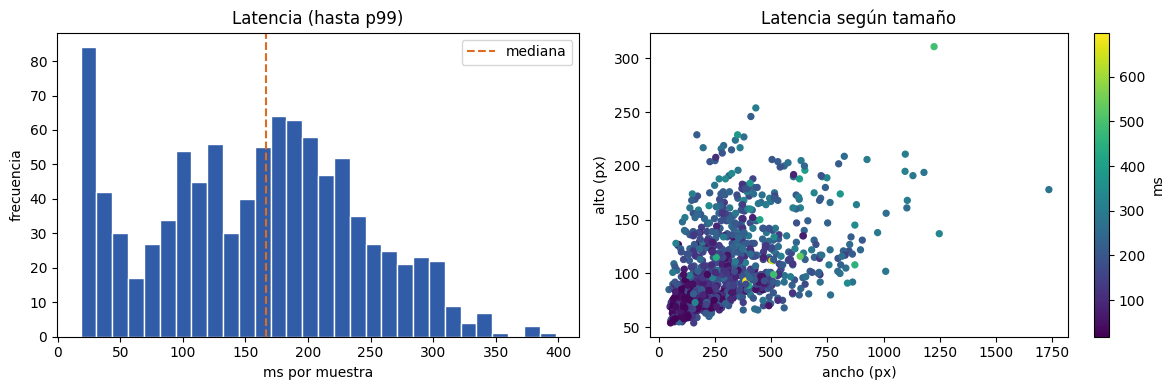

Gráfica: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\01_seleccion\resultados\benchmark_san_crohme_2014.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4)); display_limit = np.percentile(valid['time_ms'], 99)
axes[0].hist(valid.loc[valid['time_ms'] <= display_limit, 'time_ms'], bins=30, color='#315da8', edgecolor='white'); axes[0].axvline(summary['latency_median_ms'], color='#dd6b20', linestyle='--', label='mediana')
axes[0].set(title='Latencia (hasta p99)', xlabel='ms por muestra', ylabel='frecuencia'); axes[0].legend()
scatter = axes[1].scatter(valid['width'], valid['height'], c=valid['time_ms'], cmap='viridis', s=18); axes[1].set(title='Latencia según tamaño', xlabel='ancho (px)', ylabel='alto (px)'); fig.colorbar(scatter, ax=axes[1], label='ms')
fig.tight_layout(); plot_path = RESULTS_DIR / f'benchmark_san_crohme_{YEAR}.png'; fig.savefig(plot_path, dpi=160, bbox_inches='tight'); plt.show(); print('Gráfica:', plot_path)

## Lectura de los resultados

- Exact match y las tasas ≤1/≤2 usan distancia de Levenshtein sobre tokens LaTeX separados por espacios.
- CER micro agrega errores y tokens en todo el conjunto; CER macro promedia el CER de cada expresión.
- Los FLOPs son una estimación de `torch.profiler` y solo cubren los operadores soportados; se miden en una segunda inferencia independiente.
- Latencia y tiempo total contabilizan solo inferencia GPU.
- Pico incremental resta la memoria asignada inmediatamente antes de cada inferencia.